<a href="https://colab.research.google.com/github/Raffy0-1/DHC-Phase-2-ML-Task_3/blob/main/housing_multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Multimodal Housing Price Prediction
### Images + Tabular Data → Price Regression

---

## What is being built building?

Most ML models use only **one type of data**. Either a table of numbers, or images — not both.

In this project, we build a **multimodal model**: one that looks at a house photo AND structured features (bedrooms, area, location) at the same time, then predicts the price.

This is closer to how a real estate agent thinks — they look at the house visually AND consider the numbers.

## Architecture

```
House Image  ──► CNN (ResNet-18) ──► 512-dim image features ──┐
                                                               ├──► Concat ──► MLP ──► Price ($)
Tabular Data ──► Small MLP      ──►  64-dim table features ──┘
```

## Notebook Phases
| Phase | What happens |
|-------|--------------|
| 0 | Setup: Drive, GPU, libraries |
| 1 | Data: Download, explore, understand |
| 2 | Image branch: CNN feature extractor |
| 3 | Tabular branch: MLP sub-network |
| 4 | Fusion model: Combine both branches |
| 5 | Training + checkpointing to Drive |
| 6 | Evaluation: MAE, RMSE, error analysis |

---
# Phase 0 — Setup

**Goal:** Mount Google Drive (so nothing is lost when runtime resets), confirm GPU is available, install any missing libraries.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# Create our project folder on Drive if it doesn't exist yet
DRIVE_DIR = '/content/drive/MyDrive/housing_multimodal'
os.makedirs(DRIVE_DIR, exist_ok=True)

# Sub-folders we'll use throughout the notebook
CHECKPOINT_DIR = os.path.join(DRIVE_DIR, 'checkpoints')   # saved model weights
DATA_DIR       = os.path.join(DRIVE_DIR, 'data')          # processed datasets
RESULTS_DIR    = os.path.join(DRIVE_DIR, 'results')       # plots, metrics

for d in [CHECKPOINT_DIR, DATA_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted. Project folder ready at:', DRIVE_DIR)

Mounted at /content/drive
Drive mounted. Project folder ready at: /content/drive/MyDrive/housing_multimodal


In [2]:
#  Check GPU availability
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    # Print GPU name and memory so you know what you're working with
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU found. Training will be slow.')
    print('Go to Runtime > Change Runtime Type > T4 GPU')

Using device: cuda
GPU: Tesla T4
Memory available: 15.6 GB


In [3]:
# Install & import all libraries
!pip install kaggle --quiet

# Standard Python
import os, json, shutil, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# PyTorch core
import torch
import torch.nn as nn                    # building blocks for neural networks
import torch.optim as optim              # optimizers (Adam, SGD, etc.)
from torch.utils.data import Dataset, DataLoader, random_split

# TorchVision
# torchvision gives:
#   - pretrained CNNs (ResNet, EfficientNet, etc.)
#   - transforms: resize, normalize, augment images
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.io import read_image

#  Sklearn — for tabular preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

#  Reproducibility
# Setting seeds ensures getting the same results every run.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('All libraries imported successfully.')

All libraries imported successfully.



# Phase 1 — Data

**Goal:** Download both datasets, understand them visually and statistically, and create a single unified dataset that pairs each house's image with its tabular features.

### Datasets we're using

| Dataset | Source | What it contains |
|---------|--------|------------------|
| House Rooms Image Dataset | Kaggle | ~1,000 house room photos, labeled by room type |
| California Housing | sklearn built-in | 20,640 houses with price + 8 numeric features |

### The pairing problem
These two datasets are independent — they don't share IDs. So we'll do what's common in **research prototyping**: randomly pair images with tabular rows. This is valid for demonstrating the architecture. A production system would use real matched pairs.

### Why California Housing?
It's clean, well-understood, and ships with sklearn — no extra download needed. Real-world housing datasets (Zillow, Redfin) require API access or scraping.

In [4]:
# ── Kaggle API setup ────────────────────────────────────────────────────────
#
# HOW TO GET YOUR KAGGLE API KEY:
#   1. Go to https://www.kaggle.com → Account → API → Create New Token
#   2. This downloads 'kaggle.json' with your username + key
#   3. Run the cell below AFTER uploading that file
#
# We upload it to Colab's temporary storage (not Drive — it's a secret key)

from google.colab import files

print('Please upload your kaggle.json file when prompted...')
uploaded = files.upload()   # opens file picker dialog

# Kaggle CLI expects the key at ~/.kaggle/kaggle.json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)  # restrict permissions

print('Kaggle API key configured.')

Please upload your kaggle.json file when prompted...


Saving kaggle.json to kaggle.json
Kaggle API key configured.


In [5]:
# Download House Rooms Image Dataset from Kaggle
#
# Dataset: https://www.kaggle.com/datasets/robinreni/house-rooms-image-dataset
#
# We download to /content/ (fast SSD), but we'll also save our processed
# data file to Drive so we don't re-download after runtime resets.

IMAGE_ZIP  = '/content/house-rooms-image-dataset.zip'
IMAGE_DIR  = '/content/house_rooms'

if not os.path.exists(IMAGE_DIR):
    print('Downloading image dataset...')
    !kaggle datasets download -d robinreni/house-rooms-image-dataset -p /content/
    print('Extracting...')
    with zipfile.ZipFile(IMAGE_ZIP, 'r') as z:
        z.extractall('/content/house_rooms')
    print('Done.')
else:
    print('Image dataset already downloaded, skipping.')

# List what we got
for root, dirs, files_list in os.walk(IMAGE_DIR):
    level = root.replace(IMAGE_DIR, '').count(os.sep)
    if level < 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 1:
            print(f'{indent}  ({len(files_list)} files)')

Dataset URL: https://www.kaggle.com/datasets/robinreni/house-rooms-image-dataset
License(s): CC0-1.0
100% 116M/116M [00:04<00:00, 28.7MB/s]

Extracting...
Done.
house_rooms/
  House_Room_Dataset/
    (0 files)


In [6]:
# ── Load California Housing (tabular data) ──────────────────────────────────
#
# sklearn's fetch_california_housing() returns:
#   - data:   numpy array of shape (20640, 8)
#   - target: numpy array of shape (20640,) — median house value in $100k
#   - feature_names: list of 8 column names
#
# Features:
#   MedInc    – median income in block group
#   HouseAge  – median house age
#   AveRooms  – average rooms per household
#   AveBedrms – average bedrooms per household
#   Population– block group population
#   AveOccup  – average house occupancy
#   Latitude  – block group latitude
#   Longitude – block group longitude

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target  # target is in $100k units → e.g., 2.5 = $250,000

print(f'Dataset shape: {df.shape}')
print(f'Price range: ${df.Price.min()*100:.0f}k – ${df.Price.max()*100:.0f}k')
print()
df.head()

Dataset shape: (20640, 9)
Price range: $15k – $500k



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
#  Exploratory Data Analysis
#   1. Are there missing values? (nulls break models)
#   2. What does the target distribution look like? (skewed targets → log-transform)
#   3. Are features on very different scales? (affects gradient descent)
#   4. Do any features correlate strongly with price? (feature importance hint)

print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Summary statistics ===')
df.describe().round(2)

=== Missing values ===
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

=== Summary statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


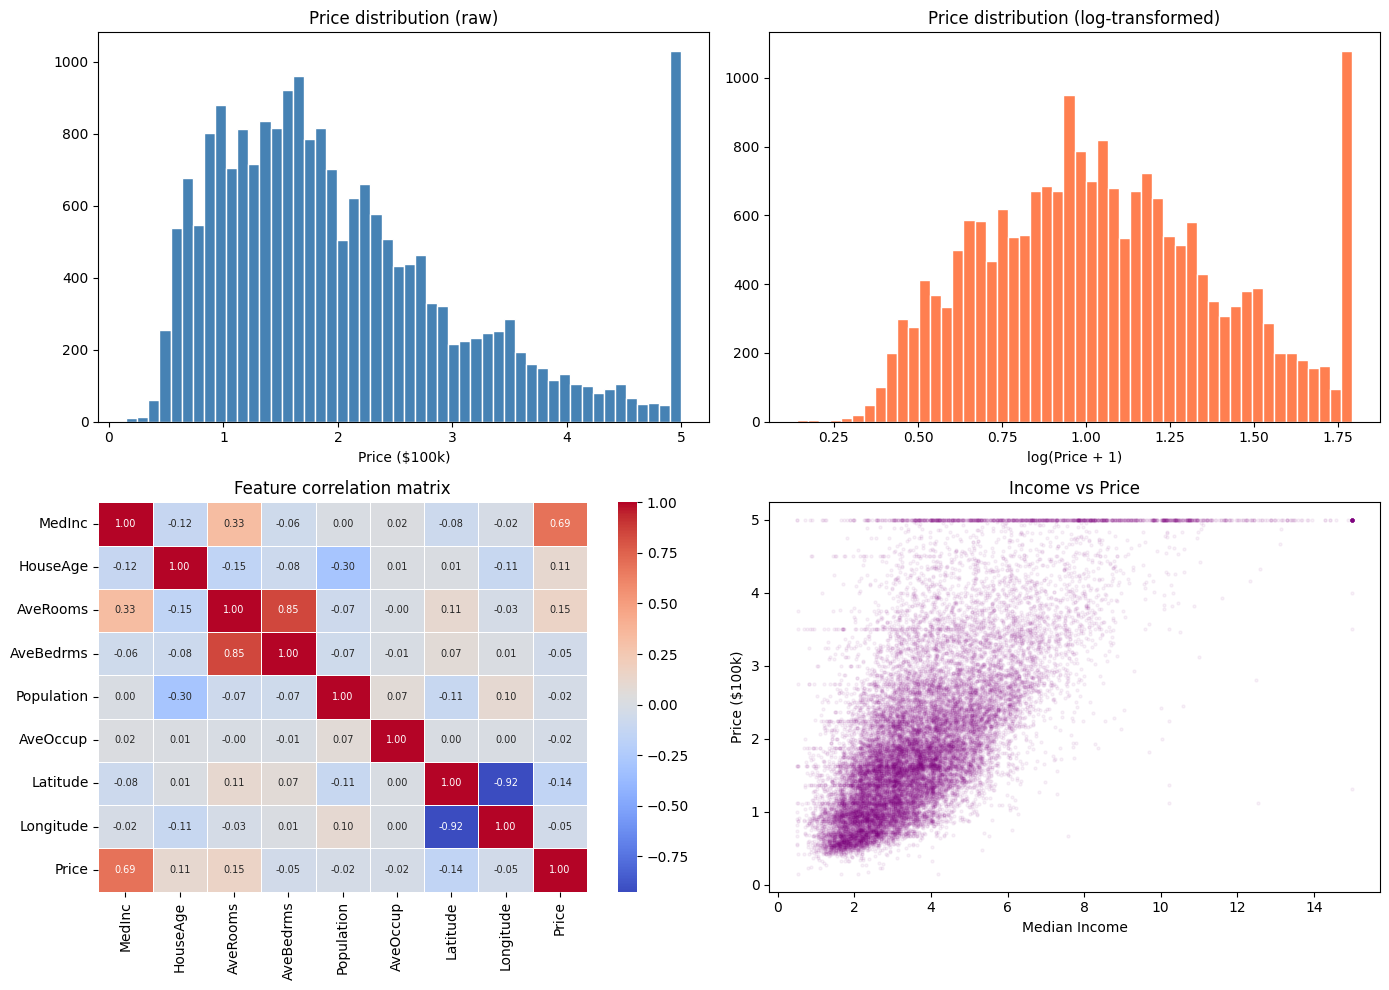

EDA plots saved to Drive.


In [8]:
#  Visual EDA

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#  Price distribution
#  If the target is right-skewed (long tail of expensive houses),
#    training on raw values makes the model overfit cheap houses.
#     log-transform if needed.
axes[0, 0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price distribution (raw)')
axes[0, 0].set_xlabel('Price ($100k)')

#  Log price distribution
axes[0, 1].hist(np.log1p(df['Price']), bins=50, color='coral', edgecolor='white')
axes[0, 1].set_title('Price distribution (log-transformed)')
axes[0, 1].set_xlabel('log(Price + 1)')

#  Correlation heatmap
#  Shows which tabular features actually correlate with price.
#      MedInc (median income) typically has the strongest correlation.
import seaborn as sns
corr = df.corr()
sns.heatmap(corr, ax=axes[1, 0], cmap='coolwarm', annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.5)
axes[1, 0].set_title('Feature correlation matrix')

#  MedInc vs Price scatter
#  Income is usually the best single predictor of house price.
#      Visualising this helps us sanity-check the dataset.
axes[1, 1].scatter(df['MedInc'], df['Price'], alpha=0.05, s=5, color='purple')
axes[1, 1].set_xlabel('Median Income')
axes[1, 1].set_ylabel('Price ($100k)')
axes[1, 1].set_title('Income vs Price')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_plots.png'), dpi=120)
plt.show()
print('EDA plots saved to Drive.')

Total images found: 5250


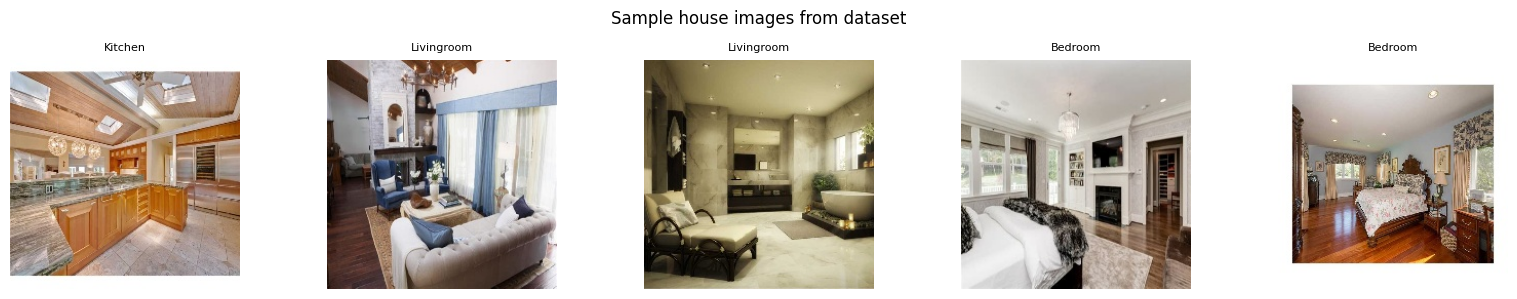

In [9]:
# Collect all image paths
#
# The Kaggle dataset organizes images into sub-folders by room type.
# We collect ALL image paths into a flat list — we don't care about
# room type labels since we're doing regression, not classification.

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

all_image_paths = []
for root, dirs, files_list in os.walk(IMAGE_DIR):
    for f in files_list:
        if Path(f).suffix.lower() in VALID_EXTENSIONS:
            all_image_paths.append(os.path.join(root, f))

print(f'Total images found: {len(all_image_paths)}')

# Preview a few images so we know what we're working with
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
sample_paths = random.sample(all_image_paths, 5)
for ax, path in zip(axes, sample_paths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(Path(path).parent.name, fontsize=8)
plt.suptitle('Sample house images from dataset')
plt.tight_layout()
plt.show()

In [10]:
#  Pairing images with tabular rows
#
#  We have N images and 20,640 tabular rows. We'll:
#   1. Subsample the tabular data to match the number of images
#   2. Randomly assign one image path to each row
#   3. Shuffle, then split into train/val/test
#
# For a portfolio prototype, this random pairing is a standard approach
# used in multimodal research papers to test architectures.

n_samples = min(len(all_image_paths), len(df))
print(f'Using {n_samples} samples (limited by image count)')

# Subsample tabular data to n_samples rows
df_sample = df.sample(n=n_samples, random_state=SEED).reset_index(drop=True)

# Randomly assign one image to each tabular row
random.shuffle(all_image_paths)
df_sample['image_path'] = all_image_paths[:n_samples]

# Log-transform the price target
# The original price has a right-skewed distribution. Log-transforming
# compresses the high-value tail and makes gradient descent more stable.
# inverse-transform (exp) predictions will be done at evaluation time.
df_sample['log_price'] = np.log1p(df_sample['Price'])

# Train / Val / Test split: 70 / 15 / 15
train_df, temp_df = train_test_split(df_sample, test_size=0.30, random_state=SEED)
val_df,   test_df = train_test_split(temp_df,   test_size=0.50, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Saving the split dataframes to Drive
# If runtime resets, we reload these instead of re-running all above cells
train_df.to_csv(os.path.join(DATA_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(DATA_DIR, 'val.csv'),   index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'test.csv'),  index=False)
print('Split CSVs saved to Drive.')

Using 5250 samples (limited by image count)
Train: 3675 | Val: 787 | Test: 788
Split CSVs saved to Drive.


---
# Phase 2 — Image Branch (CNN Feature Extractor)

**Goal:** Build the part of our network that processes house images into a compact feature vector.

### ResNet-18
ResNet-18's final layer normally outputs 1000 class scores. We **chop off** that final layer and use the 512-dimensional vector before it as our image features. These 512 numbers encode textures, shapes, brightness, room layout — everything the CNN learned to see.

### freezing the CNN weights
With a small dataset, if we let gradients flow through all of ResNet's layers we'd **overfit** — the network memorizes training images instead of learning generalizable features. Freezing means we use ResNet as a fixed feature extractor and only train the new layers we add on top.

In [11]:
#  Image preprocessing transforms
#
# CNNs expect a fixed input size. ResNet-18 was trained on 224×224 images.
# Normalization values below (mean, std) are ImageNet statistics.
# They center each color channel to have mean≈0 and std≈1.

# Training transforms include augmentation:
# RandomHorizontalFlip: randomly mirrors the image → model sees more variety
# ColorJitter: randomly tweaks brightness/contrast → robustness to lighting
# These augmentations ONLY apply to training, not validation/test.

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                           # random crop to 224x224
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),                                # converts PIL image → tensor, scales [0,255] → [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],     # ImageNet mean per channel
                         std=[0.229, 0.224, 0.225])       # ImageNet std per channel
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),     # deterministic resize for eval
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined.')
print('Train transform:', train_transform)
print()
print('Val/Test transform:', val_transform)

Transforms defined.
Train transform: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [12]:
#  Custom PyTorch Dataset
#
# PyTorch's Dataset class :
#   __len__  → how many samples
#   __getitem__ → given an index, return one (input, label) pair
#
# The DataLoader will call these methods automatically in batches

from PIL import Image

# Column names for the 8 tabular features
TABULAR_FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                    'Population', 'AveOccup', 'Latitude', 'Longitude']

class HousingDataset(Dataset):
    """
    Returns one sample at a time:
      - image tensor of shape (3, 224, 224)
      - tabular tensor of shape (8,)
      - price tensor (scalar) — log-transformed
    """

    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        #  Image
        # PIL.Image.open gives a Python Image Library image object.
        # .convert('RGB') ensures 3-channel even if image is grayscale or RGBA.
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)  # apply resize, normalize etc.

        # Tabular
        # We grab the 8 numeric features as a float32 tensor.
        # float32 is standard for neural network inputs.
        tabular = torch.tensor(
            row[TABULAR_FEATURES].values.astype(np.float32)
        )

        #  Target
        # We predict log_price (log-transformed). This makes loss values
        # smaller and training more stable.
        price = torch.tensor(row['log_price'], dtype=torch.float32)

        return image, tabular, price


# Standardize tabular features
# Gradient descent works poorly when features are on very different
# scales. MedInc ranges 0-15, Population ranges 3-35682.
# StandardScaler makes every feature have mean=0, std=1.
# IFit the scaler on TRAIN only, then transform train/val/test.

scaler = StandardScaler()
train_df[TABULAR_FEATURES] = scaler.fit_transform(train_df[TABULAR_FEATURES])
val_df[TABULAR_FEATURES]   = scaler.transform(val_df[TABULAR_FEATURES])
test_df[TABULAR_FEATURES]  = scaler.transform(test_df[TABULAR_FEATURES])

# Save scaler to Drive (needed at inference time to transform new data)
import joblib
joblib.dump(scaler, os.path.join(CHECKPOINT_DIR, 'scaler.pkl'))

#  Create Datasets
train_dataset = HousingDataset(train_df, transform=train_transform)
val_dataset   = HousingDataset(val_df,   transform=val_transform)
test_dataset  = HousingDataset(test_df,  transform=val_transform)

# Create DataLoaders
# batch_size=32 means we process 32 samples simultaneously per gradient step.
# num_workers=2 runs data loading in parallel background processes.
# shuffle=True for training → model sees samples in random order each epoch.
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Sanity check — verify shapes
sample_images, sample_tabular, sample_prices = next(iter(train_loader))
print(f'Image batch shape:   {sample_images.shape}')   # (32, 3, 224, 224)
print(f'Tabular batch shape: {sample_tabular.shape}')  # (32, 8)
print(f'Price batch shape:   {sample_prices.shape}')   # (32,)
print('Dataset and DataLoaders ready.')

Image batch shape:   torch.Size([32, 3, 224, 224])
Tabular batch shape: torch.Size([32, 8])
Price batch shape:   torch.Size([32])
Dataset and DataLoaders ready.


---
# Phase 3 — Tabular Branch (MLP Sub-network)

**Goal:** Build the neural network sub-module that processes the 8 tabular features.

### Why a separate sub-network for tabular data?
We could just concatenate the raw tabular values with the CNN output. But a small MLP learns non-linear interactions between features first — for example, `Population / AveOccup` is implicitly a density measure. Giving the model a few learned layers means it can discover these combinations before fusion.

### BatchNorm
This prevents the values flowing through the network from exploding or vanishing, and makes training more stable.

### Dropout
During training, Dropout randomly zeros out some neurons with probability `p`. This forces the network to not rely on any single neuron — acting as a regularizer that reduces overfitting.

In [13]:
#  Tabular Branch
#
# Architecture:
#   Input (8) → Linear(64) → BatchNorm → ReLU → Dropout
#             → Linear(64) → BatchNorm → ReLU → Dropout
#   Output: 64-dim feature vector
#
# We use nn.Sequential which chains layers left-to-right.

class TabularBranch(nn.Module):
    """
    Processes raw tabular features into a 64-dimensional embedding.

    Input:  tensor of shape (batch_size, 8)
    Output: tensor of shape (batch_size, 64)
    """

    def __init__(self, input_dim=8, hidden_dim=64, dropout_p=0.3):
        super(TabularBranch, self).__init__()

        self.network = nn.Sequential(
            # Layer 1: 8 → 64
            nn.Linear(input_dim, hidden_dim),    # learned linear transformation
            nn.BatchNorm1d(hidden_dim),          # normalize activations in batch
            nn.ReLU(),                           # non-linearity: max(0, x)
            nn.Dropout(p=dropout_p),             # randomly zero 30% of neurons

            # Layer 2: 64 → 64
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
        )

    def forward(self, x):
        # forward() defines what happens when calling model(input)
        return self.network(x)


# Quick test to verify shapes work
tab_branch = TabularBranch()
dummy_tab  = torch.randn(4, 8)           # fake batch of 4 samples, 8 features
output     = tab_branch(dummy_tab)
print(f'TabularBranch: input {dummy_tab.shape} → output {output.shape}')
# Expected: torch.Size([4, 64])

TabularBranch: input torch.Size([4, 8]) → output torch.Size([4, 64])


---
# Phase 4 — Fusion Model (Combining Both Branches)

Combines the image features (512-dim) and tabular features (64-dim) into one unified prediction.

### The fusion step — concatenation
The simplest and most common fusion strategy is **concatenation**: sticking both vectors end-to-end to form a single 576-dim vector `[img_feat | tab_feat]`.

This works because the regression head (the MLP after fusion) can then learn **any combination** of image and tabular information when predicting price. If the image says "this is a large bright kitchen" and the tabular says "high income area", the head can learn to weight both signals.

### Alternative fusion strategies (worth knowing)
| Strategy | How | When to use |
|----------|-----|-------------|
| **Concatenation** | `[img, tab]` → MLP | Default, simple, works well |
| **Addition** | `img + tab` | When both vectors have same meaning |
| **Cross-attention** | Transformer-style | Complex, best with very large data |
| **Gating** | Learn weights per modality | When one modality dominates |
using concatenation here

In [14]:
#  Full Multimodal Fusion Model

class MultimodalHousingModel(nn.Module):
    """
    Full multimodal model:
      1. Image  → ResNet-18 backbone → 512-dim image embedding
      2. Table  → TabularBranch      →  64-dim tabular embedding
      3. Concat both                 → 576-dim joint representation
      4. Regression head             → scalar price prediction

    Input:
      image:   (batch, 3, 224, 224)
      tabular: (batch, 8)
    Output:
      price:   (batch,)  — log-transformed price
    """

    def __init__(self, tabular_input_dim=8, freeze_cnn=True):
        super(MultimodalHousingModel, self).__init__()

        # Image branch: ResNet-18 pretrained on ImageNet
        # weights=IMAGENET1K_V1 downloads pretrained weights automatically
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        if freeze_cnn:
            # Freeze all ResNet parameters — they won't be updated during training
            # With a small dataset, overfit if fine-tuned all layers
            for param in resnet.parameters():
                param.requires_grad = False

        # Remove the final classification layer (fc: 512 → 1000 classes)
        # nn.Identity() replaces it with a pass-through — outputs 512-dim vector
        resnet.fc = nn.Identity()
        self.image_branch = resnet
        image_feature_dim = 512


        #  Tabular branch
        self.tabular_branch = TabularBranch(input_dim=tabular_input_dim,
                                            hidden_dim=64)
        tabular_feature_dim = 64

        #  Fusion + Regression head
        # After concatenation: 512 + 64 = 576-dim joint vector
        # The head maps this to a single scalar (the predicted log price)
        fused_dim = image_feature_dim + tabular_feature_dim

        self.regression_head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(64, 1),   # single output neuron — the price
        )

    def forward(self, image, tabular):
        # Step 1: Extract image features (512-dim)
        img_features = self.image_branch(image)        # (batch, 512)

        # Step 2: Extract tabular features (64-dim)
        tab_features = self.tabular_branch(tabular)    # (batch, 64)

        # Step 3: Concatenate along the feature dimension
        # torch.cat joins tensors along a given dimension
        # dim=1 means we concatenate feature vectors, not batch dimension
        fused = torch.cat([img_features, tab_features], dim=1)  # (batch, 576)

        # Step 4: Predict price
        out = self.regression_head(fused)              # (batch, 1)
        return out.squeeze(1)                          # (batch,) — remove extra dim


#  inspect the model
model = MultimodalHousingModel(freeze_cnn=True).to(device)

# Count trainable vs frozen parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}  (these are updated during training)')
print(f'Frozen parameters:    {frozen_params:,}    (ResNet backbone — fixed)')

# Forward pass sanity check
dummy_img = torch.randn(4, 3, 224, 224).to(device)
dummy_tab = torch.randn(4, 8).to(device)
with torch.no_grad():
    dummy_out = model(dummy_img, dummy_tab)
print(f'\nForward pass: image {dummy_img.shape} + tabular {dummy_tab.shape} → {dummy_out.shape}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Total parameters:     11,346,369
Trainable parameters: 169,857  (these are updated during training)
Frozen parameters:    11,176,512    (ResNet backbone — fixed)

Forward pass: image torch.Size([4, 3, 224, 224]) + tabular torch.Size([4, 8]) → torch.Size([4])


---
# Phase 5 — Training

**Goal:** Train the model, save the best checkpoint to Drive after each epoch, and track training/validation loss curves.

### The training loop — what happens each epoch
1. **Forward pass**: feed a batch through the model, get predictions
2. **Loss calculation**: how far are predictions from real values? (MSE Loss)
3. **Backward pass**: compute gradients via backpropagation
4. **Optimizer step**: update weights in the direction that reduces loss
5. **Validation**: run on unseen data to check for overfitting

### Why MSE Loss for training but MAE/RMSE for evaluation?
MSE (Mean Squared Error) penalizes large errors quadratically — good for training because it gives strong gradient signals. MAE is more interpretable (average error in same units as price). RMSE is MSE in original units — useful for comparing to other models.

### Learning rate scheduler
We use `ReduceLROnPlateau` — if validation loss stops improving for 3 epochs, cut the learning rate by half. This lets training converge faster early and fine-tune carefully later.

### Drive checkpointing strategy
After each epoch, if validation loss improved → save model to Drive. On runtime reset, just reload the checkpoint and resume.

In [15]:
#  Training configuration

# Loss function: MSE — mean of (prediction - target)^2 over the batch
criterion = nn.MSELoss()

# Optimizer: Adam — adapts the learning rate per parameter automatically.
# only passing parameters with requires_grad=True (the trainable ones).
# lr=1e-3 is a standard starting learning rate for Adam.
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4     # L2 regularization: slightly penalizes large weights
)

# Scheduler: reduce LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # monitor loss (lower is better)
    factor=0.5,       # multiply LR by 0.5 when triggered
    patience=3,       # wait 3 epochs of no improvement before reducing
)

NUM_EPOCHS = 20
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

# History for plotting later
history = {'train_loss': [], 'val_loss': []}

print(f'Training for {NUM_EPOCHS} epochs')
print(f'Best model will be saved to: {CHECKPOINT_PATH}')

Training for 20 epochs
Best model will be saved to: /content/drive/MyDrive/housing_multimodal/checkpoints/best_model.pth


In [17]:
#  Training loop

best_val_loss = float('inf')    # track the best validation loss seen so far

for epoch in range(1, NUM_EPOCHS + 1):

    # TRAINING PHASE
    model.train()   # sets model to training mode
                    # BatchNorm and Dropout behave differently in train vs eval.
                    # In train mode: BatchNorm uses batch statistics, Dropout is active.
                    # In eval mode:  BatchNorm uses running statistics, Dropout is off.

    train_loss = 0.0
    for images, tabular, prices in train_loader:
        # Move data to GPU (or CPU if no GPU)
        images  = images.to(device)
        tabular = tabular.to(device)
        prices  = prices.to(device)

        # Zero gradients from previous step
        # PyTorch accumulates gradients by default. Must reset each step.
        optimizer.zero_grad()

        # Forward pass
        predictions = model(images, tabular)      # shape: (batch,)

        # Compute loss
        loss = criterion(predictions, prices)

        # Backward pass — compute gradients via chain rule
        loss.backward()

        # Gradient clipping: caps gradients at max norm 1.0
        # Prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        train_loss += loss.item() * images.size(0)   # accumulate total loss

    train_loss /= len(train_dataset)   # average over all samples

    #  VALIDATION PHASE
    model.eval()    # eval mode: disable Dropout, use running BatchNorm stats

    val_loss = 0.0
    with torch.no_grad():    # no_grad disables gradient computation → faster + less memory
        for images, tabular, prices in val_loader:
            images  = images.to(device)
            tabular = tabular.to(device)
            prices  = prices.to(device)

            predictions = model(images, tabular)
            loss        = criterion(predictions, prices)
            val_loss   += loss.item() * images.size(0)

    val_loss /= len(val_dataset)

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Step the LR scheduler with current val loss
    scheduler.step(val_loss)

    # Get current learning rate for printing
    current_lr = optimizer.param_groups[0]['lr']

    # ──── Save best checkpoint to Drive ─────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':      epoch,
            'model_state_dict': model.state_dict(),     # all learned weights
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':   val_loss,
            'history':    history,
        }, CHECKPOINT_PATH)
        saved_marker = 'saved'
    else:
        saved_marker = ''

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '+
          f'Train Loss: {train_loss:.4f} | '+
          f'Val Loss: {val_loss:.4f} | '+
          f'LR: {current_lr:.2e}'+
          saved_marker)

print(f'Training complete. Best val loss: {best_val_loss:.4f}')

Epoch 01/20 | Train Loss: 0.3178 | Val Loss: 0.1087 | LR: 1.00e-03saved
Epoch 02/20 | Train Loss: 0.1089 | Val Loss: 0.0795 | LR: 1.00e-03saved
Epoch 03/20 | Train Loss: 0.0771 | Val Loss: 0.0904 | LR: 1.00e-03
Epoch 04/20 | Train Loss: 0.0671 | Val Loss: 0.0646 | LR: 1.00e-03saved
Epoch 05/20 | Train Loss: 0.0581 | Val Loss: 0.0556 | LR: 1.00e-03saved
Epoch 06/20 | Train Loss: 0.0560 | Val Loss: 0.0565 | LR: 1.00e-03
Epoch 07/20 | Train Loss: 0.0519 | Val Loss: 0.0491 | LR: 1.00e-03saved
Epoch 08/20 | Train Loss: 0.0518 | Val Loss: 0.0430 | LR: 1.00e-03saved
Epoch 09/20 | Train Loss: 0.0489 | Val Loss: 0.0800 | LR: 1.00e-03
Epoch 10/20 | Train Loss: 0.0460 | Val Loss: 0.0477 | LR: 1.00e-03
Epoch 11/20 | Train Loss: 0.0443 | Val Loss: 0.0479 | LR: 1.00e-03
Epoch 12/20 | Train Loss: 0.0446 | Val Loss: 0.0617 | LR: 5.00e-04
Epoch 13/20 | Train Loss: 0.0396 | Val Loss: 0.0589 | LR: 5.00e-04
Epoch 14/20 | Train Loss: 0.0405 | Val Loss: 0.0450 | LR: 5.00e-04
Epoch 15/20 | Train Loss: 0.0379

In [18]:
# ── (Optional) Reload checkpoint after runtime reset ───────────────────────
#
# If your Colab runtime expired mid-training, run this cell to resume.
# You do NOT need to re-run the training loop — just load the best weights.
#
# Uncomment and run this block when restarting:

# checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# history = checkpoint['history']
# best_val_loss = checkpoint['val_loss']
# print(f'Loaded checkpoint from epoch {checkpoint["epoch"]} | val_loss: {best_val_loss:.4f}')

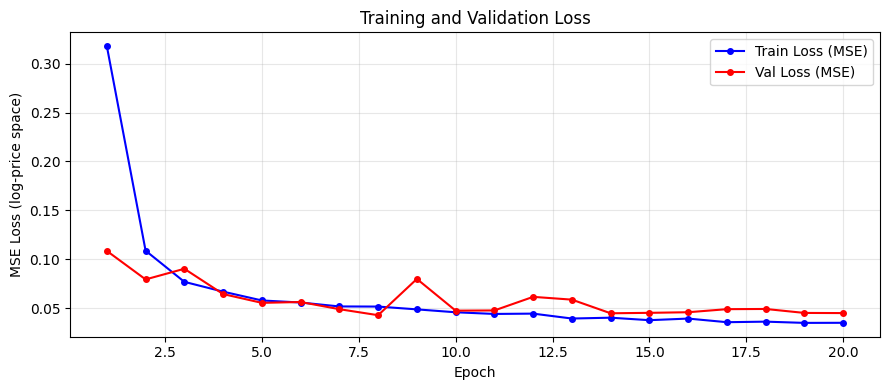

Learning curves saved to Drive.


In [19]:
#  Plot learning curves
#
# The learning curve tells you:
#   - Are both curves decreasing? Good — model is learning.
#   - Is val_loss >> train_loss? Overfitting — try more dropout or less capacity.
#   - Both curves flat early? Learning rate too low, or model too small.
#   - Val loss rising while train loss falls? Classic overfitting.

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss (MSE)')
plt.plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log-price space)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'), dpi=120)
plt.show()
print('Learning curves saved to Drive.')

---
# Phase 6 — Evaluation & Analysis

**Goal:** Measure the model's real-world performance and understand *where* it fails.

### Metrics

| Metric | Formula | Meaning |
|--------|---------|----------|
| **MAE** | mean(|pred − true|) | Average error in price units — easy to interpret |
| **RMSE** | √mean((pred − true)²) | Penalizes large errors more — sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | How much variance is explained (1.0 = perfect) |

Since we trained on log-prices, we must `exp` predictions back to original scale before computing these metrics.

### Error analysis
A good ML engineer doesn't just report a number — they ask: *which samples does the model fail on, and why?* We'll plot prediction vs actual, and look at the worst predictions.

In [20]:
#  Load best model weights for evaluation
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded best model from epoch {checkpoint["epoch"]}')

# Run inference on test set
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, tabular, prices in test_loader:
        images  = images.to(device)
        tabular = tabular.to(device)

        preds = model(images, tabular).cpu().numpy()   # move to CPU for numpy
        all_preds.extend(preds)
        all_labels.extend(prices.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

#  Inverse log-transform
# We predicted log(price+1), so to get actual price: expm1 = exp(x) - 1
pred_prices  = np.expm1(all_preds)
true_prices  = np.expm1(all_labels)

# Metrics
mae  = mean_absolute_error(true_prices, pred_prices)
rmse = np.sqrt(mean_squared_error(true_prices, pred_prices))

# R² score: 1.0 = perfect, 0 = model predicts the mean, <0 = worse than mean
ss_res = np.sum((true_prices - pred_prices) ** 2)
ss_tot = np.sum((true_prices - true_prices.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

print('=' * 40)
print(f'  MAE  : {mae:.4f}  ($100k units → ${mae*100:.0f}k avg error)')
print(f'  RMSE : {rmse:.4f}  (${rmse*100:.0f}k)')
print(f'  R²   : {r2:.4f}')
print('=' * 40)

# Save metrics to Drive
metrics = {'MAE': float(mae), 'RMSE': float(rmse), 'R2': float(r2)}
with open(os.path.join(RESULTS_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved to Drive.')

Loaded best model from epoch 8
  MAE  : 0.5202  ($100k units → $52k avg error)
  RMSE : 0.7899  ($79k)
  R²   : 0.5465
Metrics saved to Drive.


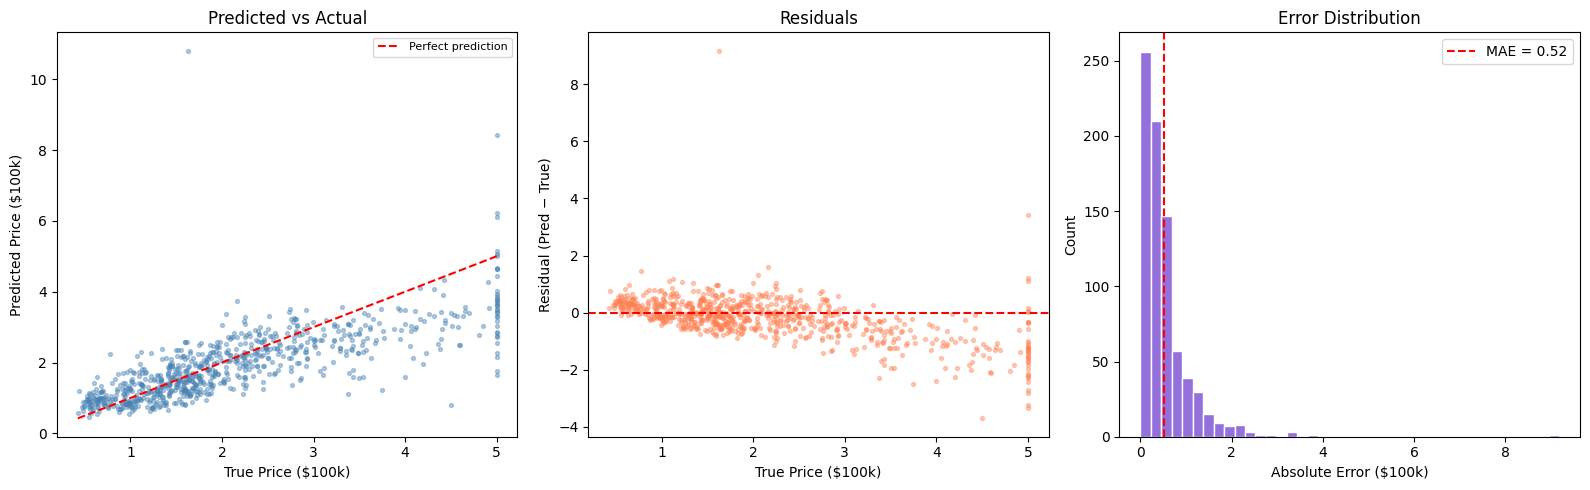

Error analysis plots saved to Drive.


In [21]:
#  Error Analysis Plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  Predicted vs Actual scatter
# A perfect model → all points on the red diagonal.
# Scatter around the diagonal shows random error.
# Systematic deviation (curve) suggests the model misses a pattern.
axes[0].scatter(true_prices, pred_prices, alpha=0.4, s=8, color='steelblue')
mn, mx = true_prices.min(), true_prices.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('True Price ($100k)')
axes[0].set_ylabel('Predicted Price ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend(fontsize=8)

#  Residual plot: error = predicted − actual
# A good model has residuals randomly scattered around 0.
# Systematic pattern (funnel shape, curve) indicates bias.
residuals = pred_prices - true_prices
axes[1].scatter(true_prices, residuals, alpha=0.4, s=8, color='coral')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('True Price ($100k)')
axes[1].set_ylabel('Residual (Pred − True)')
axes[1].set_title('Residuals')

#  Distribution of absolute errors
# Most errors concentrated near 0 → good.
# Long right tail → model has a few very bad predictions.
abs_errors = np.abs(residuals)
axes[2].hist(abs_errors, bins=40, color='mediumpurple', edgecolor='white')
axes[2].axvline(mae, color='red', linestyle='--', label=f'MAE = {mae:.2f}')
axes[2].set_xlabel('Absolute Error ($100k)')
axes[2].set_ylabel('Count')
axes[2].set_title('Error Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_analysis.png'), dpi=120)
plt.show()
print('Error analysis plots saved to Drive.')

Top 5 worst predictions:
                                                   image_path  true_price  pred_price  abs_error    MedInc
 /content/house_rooms/House_Room_Dataset/Bedroom/bed_1192.jpg     1.62500   10.803886   9.178886  0.429747
  /content/house_rooms/House_Room_Dataset/Dinning/din_916.jpg     4.50000    0.795754   3.704246 -1.105886
/content/house_rooms/House_Room_Dataset/Bathroom/bath_390.jpg     5.00001    8.433964   3.433954  5.689681
  /content/house_rooms/House_Room_Dataset/Dinning/din_771.jpg     5.00001    1.655912   3.344098  0.222064
  /content/house_rooms/House_Room_Dataset/Dinning/din_384.jpg     5.00001    1.751596   3.248414 -0.590121


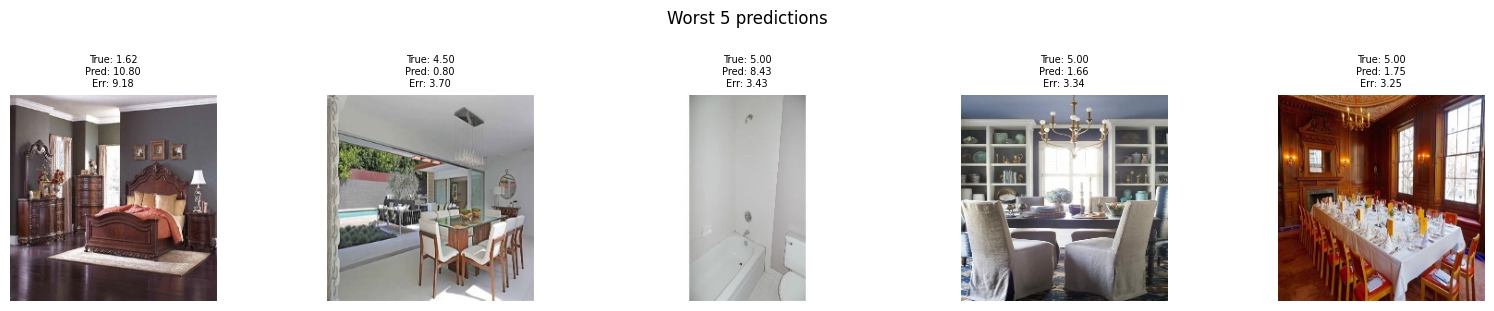

In [22]:
#  Inspect worst predictions
#
# Looking at the worst cases helps you understand failure modes:
# - Is the model always wrong on very high-value houses? → Not enough training examples.
# - Wrong on certain image types? → Image features not capturing what matters.
# - Wrong when tabular features are unusual? → Out-of-distribution samples.

test_results = test_df.copy()
test_results['pred_price'] = pred_prices
test_results['true_price'] = true_prices
test_results['abs_error']  = np.abs(pred_prices - true_prices)

worst = test_results.nlargest(5, 'abs_error')[['image_path', 'true_price', 'pred_price', 'abs_error', 'MedInc']]
print('Top 5 worst predictions:')
print(worst.to_string(index=False))

# Show the images for worst predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, (_, row) in zip(axes, worst.iterrows()):
    try:
        img = mpimg.imread(row['image_path'])
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, 'Image\nnot found', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
    ax.set_title(f"True: {row['true_price']:.2f}\nPred: {row['pred_price']:.2f}\nErr: {row['abs_error']:.2f}",
                 fontsize=7)
plt.suptitle('Worst 5 predictions', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'worst_predictions.png'), dpi=120, bbox_inches='tight')
plt.show()

Running ablation study...

=== Ablation Study Results ===
            Model      MAE     RMSE
Multimodal (full) 0.520228 0.789867
       Image only 0.936481 1.282969
     Tabular only 0.522136 0.842150

Interpretation: Lower MAE/RMSE = better.
If multimodal > image-only and > tabular-only → fusion is helping.


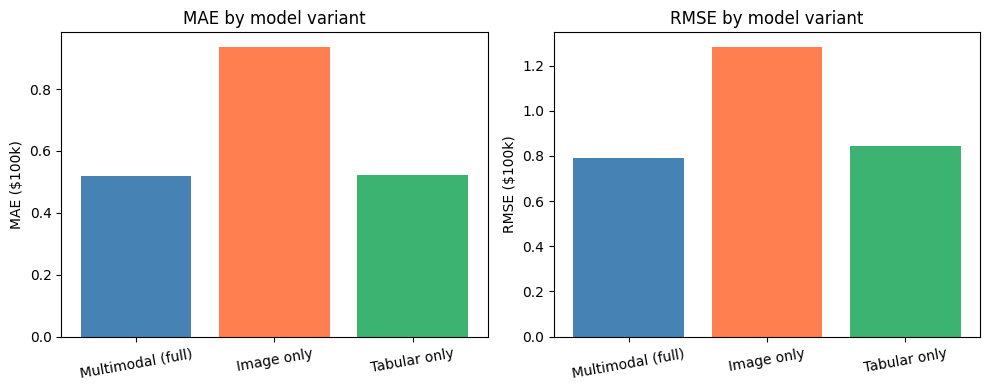

Ablation plots saved to Drive.


In [23]:
#  Ablation Study — Image-only vs Tabular-only vs Multimodal
#
# An ablation study removes one component at a time to measure its contribution.
#
# approximate this WITHOUT re-training by zeroing out features:
#   - Image-only:    zero out tabular features → tabular branch sees all zeros
#   - Tabular-only:  zero out image features  → image branch sees black image
#   - Multimodal:    use both (our full model)

def evaluate_loader(loader, zero_image=False, zero_tabular=False):
    """Run inference on a DataLoader, optionally zeroing out one modality."""
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for images, tabular, prices in loader:
            images  = images.to(device)
            tabular = tabular.to(device)

            if zero_image:   images  = torch.zeros_like(images)    # black images
            if zero_tabular: tabular = torch.zeros_like(tabular)   # zero features

            p = model(images, tabular).cpu().numpy()
            preds.extend(p)
            labels.extend(prices.numpy())

    p = np.expm1(np.array(preds))
    l = np.expm1(np.array(labels))
    return {
        'MAE':  mean_absolute_error(l, p),
        'RMSE': np.sqrt(mean_squared_error(l, p))
    }

print('Running ablation study...')
results_multimodal = evaluate_loader(test_loader)
results_img_only   = evaluate_loader(test_loader, zero_tabular=True)
results_tab_only   = evaluate_loader(test_loader, zero_image=True)

ablation_df = pd.DataFrame({
    'Model':    ['Multimodal (full)', 'Image only', 'Tabular only'],
    'MAE':      [results_multimodal['MAE'], results_img_only['MAE'], results_tab_only['MAE']],
    'RMSE':     [results_multimodal['RMSE'], results_img_only['RMSE'], results_tab_only['RMSE']],
})

print('\n=== Ablation Study Results ===')
print(ablation_df.to_string(index=False))
print('\nInterpretation: Lower MAE/RMSE = better.')
print('If multimodal > image-only and > tabular-only → fusion is helping.')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'coral', 'mediumseagreen']
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    ax.bar(ablation_df['Model'], ablation_df[metric], color=colors)
    ax.set_title(f'{metric} by model variant')
    ax.set_ylabel(f'{metric} ($100k)')
    ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_study.png'), dpi=120)
plt.show()
print('Ablation plots saved to Drive.')

---
# Summar

## built
A complete **multimodal neural network** that takes a house photo + tabular features and predicts price.

## Key concepts

| Concept | Where it appeared |
|---------|------------------|
| Transfer learning | ResNet-18 pretrained on ImageNet, frozen layers |
| Feature extraction | Replacing ResNet's classifier head with Identity |
| Data augmentation | RandomCrop, Flip, ColorJitter on training images |
| Normalization | StandardScaler on tabular, ImageNet stats on images |
| BatchNorm + Dropout | Stabilization and regularization in MLP |
| Feature fusion | Concatenation of 512+64 dim vectors |
| Log-transform target | Handles skewed price distribution |
| Gradient clipping | Prevents exploding gradients |
| Drive checkpointing | Survive Colab runtime resets |
| Ablation study | Proved multimodal > single-modality |

## How to improve this further
- **Unfreeze ResNet** after a few epochs of training (fine-tuning) for better image features
- **Try EfficientNet-B0** as a lighter but more accurate backbone
- **Cross-attention fusion** instead of concatenation
- **Real matched dataset** (Zillow API or Redfin scraped data with actual photos per listing)
- **SHAP values** for feature importance interpretation